# A* Experiment Analysis

This notebook processes results from the A* experiments and generates visualizations used in the final report.

All outputs are included for convenience and reproducibility.

## Script:

In [14]:
import heapq
import time
import random

def astar(grid, start, goal, heuristic):
    """
    grid: 2D list representing the grid (-1 for wall, >=1 for movement cost)
    start: tuple (x, y) starting position
    goal: tuple (x, y) goal position
    heuristic: function that takes two positions and returns an estimated cost
    """
    rows, cols = len(grid), len(grid[0])
    open_set = []
    # Push (f_score, g_score, position)
    heapq.heappush(open_set, (0, 0, start))
    came_from = {}
    g_score = {start: 0}
    nodes_expanded = 0
    start_time = time.time()
    while open_set:
        f, g, current = heapq.heappop(open_set)
        nodes_expanded += 1
        if current == goal:
            end_time = time.time()
            return {
                "path": reconstruct_path(came_from, current),
                "cost": g_score[current],
                "nodes_expanded": nodes_expanded,
                "runtime": end_time - start_time
            }
        for neighbor in get_neighbors(current, grid, rows, cols):
            tentative_g_score = g_score[current] + grid[neighbor[0]][neighbor[1]]
            if neighbor not in g_score or tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score = tentative_g_score + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score, tentative_g_score, neighbor))
    return None  # No path found

def get_neighbors(position, grid, rows, cols):
    x, y = position
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    neighbors = []
    for dx, dy in directions:
        nx, ny = x + dx, y + dy
        if 0 <= nx < rows and 0 <= ny < cols:
            # Check if walkable (not a wall)
            if grid[nx][ny] != -1:
                neighbors.append((nx, ny))
    return neighbors

def reconstruct_path(came_from, current):
    path = [current]
    while current in came_from:
        current = came_from[current]
        path.append(current)
    path.reverse()
    return path

def zero_heuristic(a, b):
    return 0

def manhattan_heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

# Weighted (non-admissible) heuristic
def weighted_manhattan(weight):
    def heuristic(a, b):
        return weight * manhattan_heuristic(a, b)
    return heuristic

def generate_layout(rows, cols, obstacle_prob=0.2, seed=45):
    random.seed(seed)
    layout = []
    for _ in range(rows):
        row = []
        for _ in range(cols):
            if random.random() < obstacle_prob:
                # Wall
                row.append(-1)
            else:
                # Walkable
                row.append(0)
        layout.append(row)
    return layout

def apply_costs(layout, weighted=False, seed=41):
    random.seed(seed)
    grid = []
    for row in layout:
        new_row = []
        for cell in row:
            if cell == -1:
                new_row.append(-1)
            else:
                if weighted:
                    new_row.append(random.randint(1, 20))
                else:
                    new_row.append(1)
        grid.append(new_row)
    return grid

# Generates a layout that guarantees a valid path exists between start and goal
def generate_valid_layout(start, goal, rows=40, cols=40, obstacle_prob=0.2, seed=51):
    while True:
        layout = generate_layout(rows, cols, obstacle_prob, seed)
        layout[start[0]][start[1]] = 0
        layout[goal[0]][goal[1]] = 0
        if astar(layout, start, goal, zero_heuristic):
            return layout
        seed += 1

def run_experiment(layout, weighted=False):
    start = (0, 0)
    goal = (39, 39)
    grid = apply_costs(layout, weighted=weighted)
    heuristics = {
        "Dijkstra": zero_heuristic,
        "Manhattan": manhattan_heuristic,
        "Weighted (1.2)": weighted_manhattan(1.2),
        "Weighted (2)": weighted_manhattan(2.0),
        "Weighted (5)": weighted_manhattan(5.0),
        "Weighted (10)": weighted_manhattan(10.0)
    }
    results = {}
    for name, h in heuristics.items():
        results[name] = astar(grid, start, goal, h)
    return results

def print_results(title, batch_results):
    print(f"\n=== {title} ===")

    for h_name, runs in batch_results.items():
        total_cost = sum(r["cost"] for r in runs)
        total_nodes = sum(r["nodes_expanded"] for r in runs)
        total_runtime = sum(r["runtime"] for r in runs)

        num_runs = len(runs)

        print(f"\n{h_name} (Averages over {num_runs} runs):")
        print(f"\tAverage Path Cost: {total_cost / num_runs:.2f}")
        print(f"\tAverage Nodes Expanded: {total_nodes / num_runs:.2f}")
        print(f"\tAverage Runtime: {total_runtime / num_runs:.6f} seconds")

# Aggregates results across all layouts for each heuristic.
def run_batch_on_layouts(layouts, weighted=False):
    aggregate_results = {}
    for i, layout in enumerate(layouts):
        results = run_experiment(layout, weighted=weighted)
        if i == 0:
            for h_name in results.keys():
                aggregate_results[h_name] = []
        for h_name, result in results.items():
            if result:
                aggregate_results[h_name].append(result)
    return aggregate_results

## Run Experiments:

In [15]:
start = (0, 0)
goal = (39, 39)
num_runs = 20
shared_layouts = []
for run_index in range(num_runs):
    seed = 51 + run_index
    layout = generate_valid_layout(start, goal, seed=seed)
    shared_layouts.append(layout)
uniform_results = run_batch_on_layouts(shared_layouts, weighted=False)
weighted_results = run_batch_on_layouts(shared_layouts, weighted=True)

## Data Processing

Averages results across runs and prepares metrics for analysis.

In [16]:
def compute_averages(results):
    avg_cost = []
    avg_nodes = []
    avg_runtime = []
    for h_name, runs in results.items():
        num_runs = len(runs)
        avg_cost.append(sum(r["cost"] for r in runs) / num_runs)
        avg_nodes.append(sum(r["nodes_expanded"] for r in runs) / num_runs)
        avg_runtime.append(sum(r["runtime"] for r in runs) / num_runs)
    return (results.keys(), avg_cost, avg_nodes, avg_runtime)

labels, uniform_cost, uniform_nodes, _ = compute_averages(uniform_results)
_, weighted_cost, weighted_nodes, _ = compute_averages(weighted_results)

## Visualization

The following plots illustrate:
 - Node expansions across heuristics
 - Path cost trends in uniform and weighted environments


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


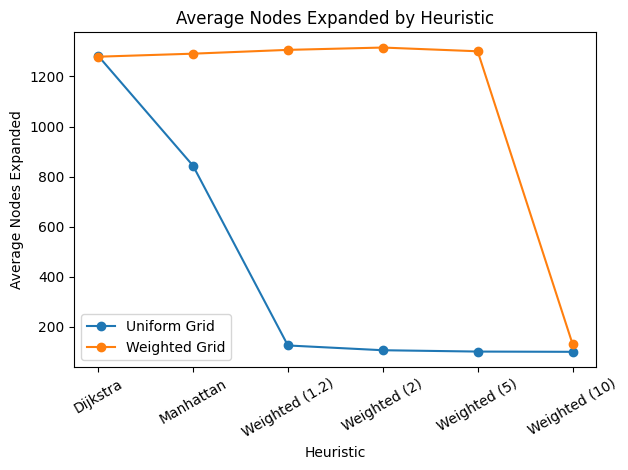

In [17]:
# Nodes Expanded Chart
import sys
!{sys.executable} -m pip install matplotlib
import matplotlib.pyplot as plt

plt.figure()
plt.plot(labels, uniform_nodes, marker='o', label='Uniform Grid')
plt.plot(labels, weighted_nodes, marker='o', label='Weighted Grid')
plt.title('Average Nodes Expanded by Heuristic')
plt.xlabel('Heuristic')
plt.ylabel('Average Nodes Expanded')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('nodes_expanded.png', dpi=300)
plt.show()

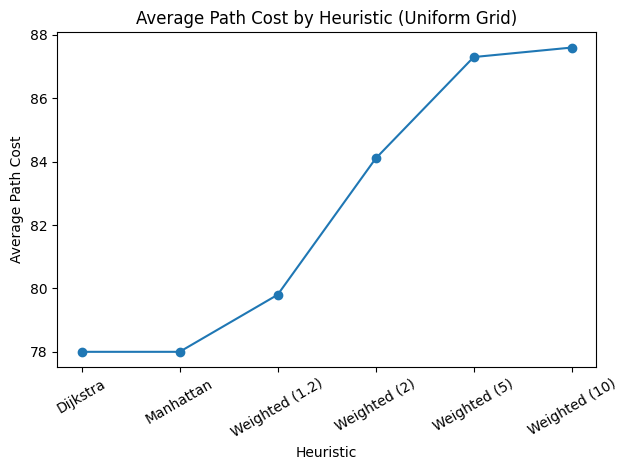

In [18]:
# Uniform cost chart
plt.figure()
plt.plot(labels, uniform_cost, marker='o')
plt.title('Average Path Cost by Heuristic (Uniform Grid)')
plt.xlabel('Heuristic')
plt.ylabel('Average Path Cost')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('path_cost_uniform.png', dpi=300)
plt.show()

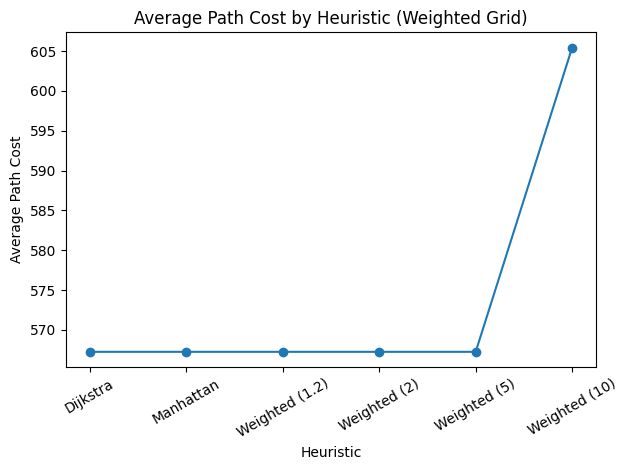

In [19]:
# Weighted cost chart
plt.figure()
plt.plot(labels, weighted_cost, marker='o')
plt.title('Average Path Cost by Heuristic (Weighted Grid)')
plt.xlabel('Heuristic')
plt.ylabel('Average Path Cost')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('path_cost_weighted.png', dpi=300)
plt.show()
